In [39]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

n_samples = 50
n_bins = 5

X = np.random.uniform(low=-6.0, high=6.0, size=(n_samples, ))


In [40]:
X.shape

(50,)

In [41]:
X

array([-5.50661492,  2.52757354, -5.47319631,  5.98569425, -4.80322849,
        0.56122554, -4.34986887,  1.43924469,  2.24770642,  2.19748003,
       -3.91793716,  5.00090882,  2.3778944 , -4.87379688,  4.11738651,
        1.27816521, -2.16274195, -1.99255132,  5.96539808,  3.214178  ,
       -5.16433243,  0.732799  , -5.31763443, -4.06747085,  3.054008  ,
       -0.74891113, -0.57726341, -3.18957143, -1.72045331,  5.25620061,
       -5.4011505 ,  1.50939781, -1.92672724, -0.58261219,  5.33882589,
       -2.50743829,  2.36676985, -2.58427543,  2.58980179,  0.13211817,
        2.17545089,  3.60118605,  2.79201914,  5.9900524 ,  3.60334959,
        3.15139529, -2.41707554,  2.68314221,  1.55228219, -0.16929553])

(array([18.,  3.,  2.,  3., 24.]),
 array([0.00404341, 0.20273527, 0.40142713, 0.600119  , 0.79881086,
        0.99750272]),
 <BarContainer object of 5 artists>)

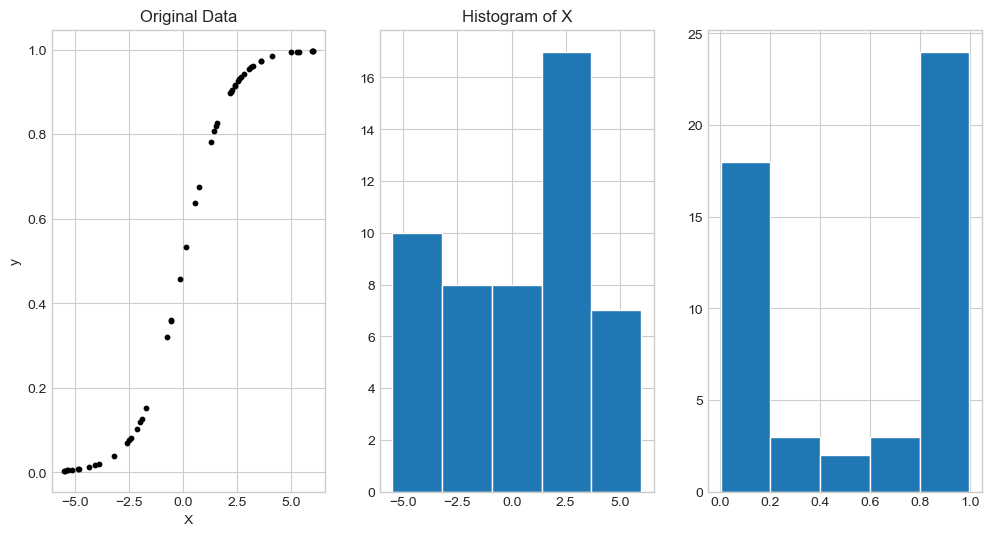

In [42]:
X = np.sort(X)
y = 1 / (1 + np.exp(-X))

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 6))

ax[0].scatter(X, y, s=10, color='black')
ax[0].set_title("Original Data")
ax[0].set_xlabel("X")
ax[0].set_ylabel("y")
ax[1].hist(X, bins=n_bins, edgecolor='white')
ax[1].set_title("Histogram of X")
ax[2].hist(y, bins=n_bins, edgecolor='white')

-5.437173404844023
-2.54585686173721
-0.01858868194465213
2.3072381338504
3.602267816832925


Text(0, 0.5, 'y')

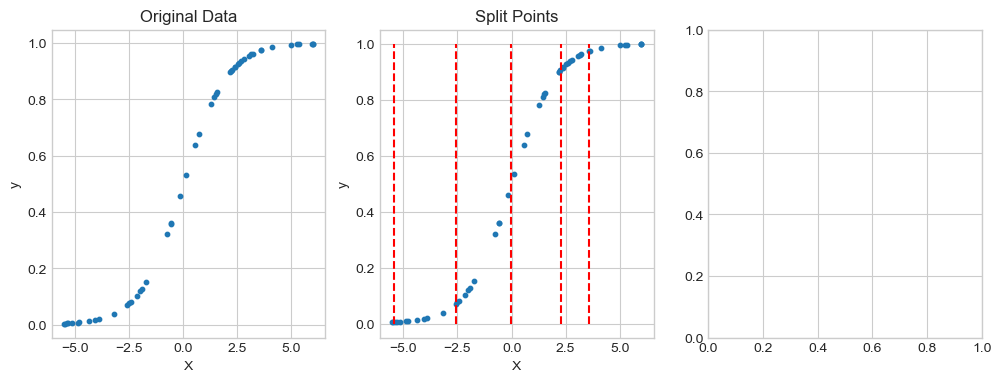

In [43]:
fig,ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))
ax[0].scatter(X, y, s=10)
ax[0].set_title("Original Data")
ax[0].set_xlabel("X")
ax[0].set_ylabel("y")

ax[1].scatter(X, y, s=10)
for i in range(1, n_samples -1, 10):
    split = (X[i] + X[i + 1]) / 2
    print(split)
    ax[1].plot([split, split], [0.0, 1.0], c='red', linestyle='--')

ax[1].set_title("Split Points")
ax[1].set_xlabel("X")
ax[1].set_ylabel("y")


(np.float64(-1.2346822177458687), np.float64(0.18510457054969123))
(np.float64(-0.5772634053938424), np.float64(0.18600097239314806))


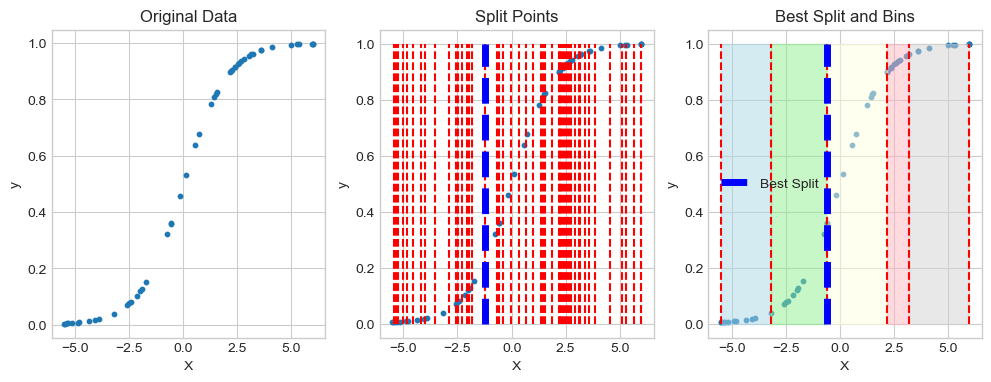

In [50]:
fig,ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))
ax[0].scatter(X, y, s=10)
ax[0].set_title("Original Data")
ax[0].set_xlabel("X")
ax[0].set_ylabel("y")
ax[1].scatter(X, y, s=10)
for i in range(1,  n_samples -1):
    split = (X[i] + X[i + 1]) / 2
    ax[1].plot([split, split], [0.0, 1.0], c='red', linestyle='--')
ax[1].set_title("Split Points")
ax[1].set_xlabel("X")
ax[1].set_ylabel("y")
best = (-np.inf, np.inf)
for i in range(1, n_samples-1):
    split = (X[i] + X[i + 1]) / 2
    loss = np.mean(y[X <= split] - np.mean(y[X <= split]) ** 2) + np.mean(y[X > split] - np.mean(y[ X > split]) ** 2)
    if loss < best[1]:
        best = (split, loss)

print(best)
ax[1].plot([best[0], best[0]], [0.0, 1.0], c='blue',linewidth=5,linestyle='--', label='Best Split')
ax[2].scatter(X, y, s=10)
splits = [X[0], X[10], X[20], X[30], X[40], X[49]]
for split in splits:
    ax[2].plot([split, split], [0.0, 1.0], c='red', linestyle='--')
bin_colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightpink', 'lightgray']
for i in range(n_bins):
    ax[2].add_patch(patches.Rectangle((splits[i], 0), splits[i + 1] - splits[i], 1, color=bin_colors[i], alpha=0.5))

ax[2].set_title("Best Split and Bins")
ax[2].set_xlabel("X")
ax[2].set_ylabel("y")
best_h = (-np.inf, np.inf)
def safe_mean(arr):
    if len(arr) == 0:
        return 0
    return np.mean(arr)
for split in splits:
    loss = safe_mean(y[X <= split] - safe_mean(y[X <= split]) ** 2) + safe_mean(y[X > split] - safe_mean(y[X > split]) ** 2)
    if loss < best_h[1]:
        best_h = (split, loss)
print(best_h)
ax[2].plot([best_h[0], best_h[0]], [0.0, 1.0], c='blue',linewidth=5,linestyle='--', label='Best Split')
plt.legend()
plt.show()


In [51]:
from sklearn.ensemble import  HistGradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingRegressor
import pandas as pd
from sklearn.datasets import load_iris

In [56]:
iris = load_iris()
type(iris)
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [59]:
iris_df = pd.DataFrame(iris.data)
iris_df.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [60]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [61]:
iris_df.columns  = iris.feature_names
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


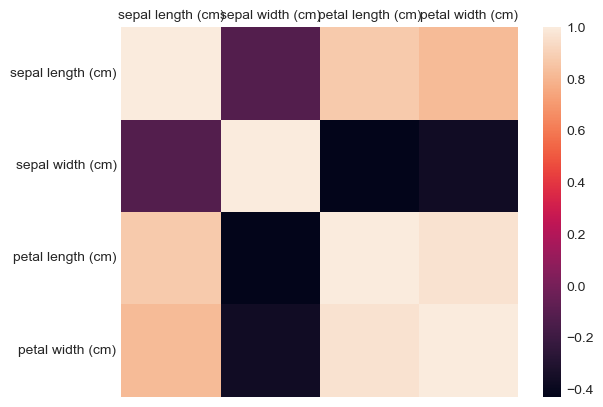

In [62]:
import seaborn as sns
ax = sns.heatmap(iris_df.corr())
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_ticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=iris.feature_names)

In [63]:
iris_df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


In [64]:
data = pd.read_csv("data/Bcard.txt", engine='c')

In [65]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 95806 entries, 0 to 95805
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   obs_mth       95806 non-null  str    
 1   bad_ind       95806 non-null  float64
 2   uid           95806 non-null  str    
 3   td_score      95806 non-null  float64
 4   jxl_score     95806 non-null  float64
 5   mj_score      95806 non-null  float64
 6   rh_score      95806 non-null  float64
 7   zzc_score     95806 non-null  float64
 8   zcx_score     95806 non-null  float64
 9   person_info   95806 non-null  float64
 10  finance_info  95806 non-null  float64
 11  credit_info   95806 non-null  float64
 12  act_info      95806 non-null  float64
dtypes: float64(11), str(2)
memory usage: 9.5 MB


In [66]:
changetype = {"uid":object, "obs_math":object}
data = pd.read_csv("data/Bcard.txt", engine='c', dtype=changetype)
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 95806 entries, 0 to 95805
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   obs_mth       95806 non-null  str    
 1   bad_ind       95806 non-null  float64
 2   uid           95806 non-null  object 
 3   td_score      95806 non-null  float64
 4   jxl_score     95806 non-null  float64
 5   mj_score      95806 non-null  float64
 6   rh_score      95806 non-null  float64
 7   zzc_score     95806 non-null  float64
 8   zcx_score     95806 non-null  float64
 9   person_info   95806 non-null  float64
 10  finance_info  95806 non-null  float64
 11  credit_info   95806 non-null  float64
 12  act_info      95806 non-null  float64
dtypes: float64(11), object(1), str(1)
memory usage: 9.5+ MB
